## Q6: PCA



### How PCA Works

PCA transforms the original features into a new set of uncorrelated features called **principal components**. These components are ordered such that:

- The **first principal component (PC1)** captures the direction of maximum variance.
- The **second principal component (PC2)** captures the next highest variance in a direction orthogonal to PC1.
- And so on.

Choose the top $k$ principal components that together explain a significant portion (e.g., 90%) of the total variance.


### Deciding the Number of Components ($k$)

The number of principal components $k$ is chosen based on the cumulative variance explained.  
Typically, we select the smallest $k$ such that:

$$ \text{Cumulative Variance} \geq 85\% \text{ or } 90\% $$

This ensures that the reduced dataset still retains most of the important information.



### Benefits of PCA


- **Computational Efficiency** improves significantly.
- **Storage Requirements** decrease.
- **Model Generalization** enhances, reducing overfitting risks.
- **Visualization** becomes feasible (e.g., 2D or 3D scatter plots of complex data).




**1.)** Generate the scatter plot giiven in 1a 

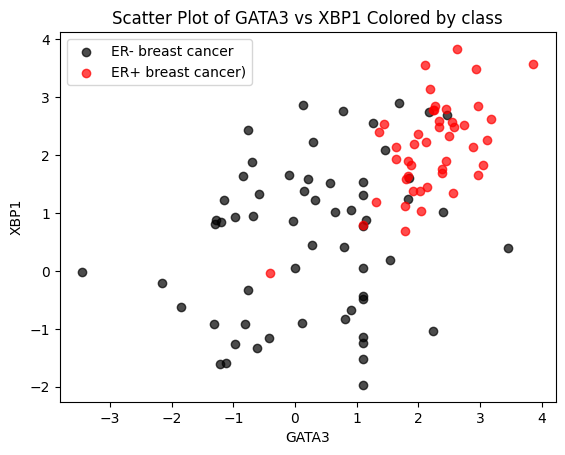

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("filtered.tsv", sep="\t")
df1 = pd.read_csv("class.tsv", sep="\t", header=None)
df2 = pd.read_csv("columns.tsv", sep="\t", comment="#")    

x1 = (df2.loc[df2['GeneSymbol'] == 'GATA3', 'ID'].values[0])
y1 = df2.loc[df2['GeneSymbol'] == 'XBP1', 'ID'].values[0]

x1 = " " + str(x1)
y1 = " " + str(y1)

X = df[x1].values
Y = df[y1].values
Z = df1[0].values

mask0 = (Z == 0)
mask1 = (Z == 1)

# Plot
plt.scatter(X[mask0], Y[mask0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(X[mask1], Y[mask1], color='red', alpha=0.7, label='ER+ breast cancer)')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by class")
plt.legend()
plt.show()



### Steps to perform PCA:

- Center the data

- Compute covariance matrix

- Find the eigen values and the eigen vectors

- Sort eigenvectors by descending eigenvalue

- Take the top 2 eigenvectors as the principle components 1 and 2

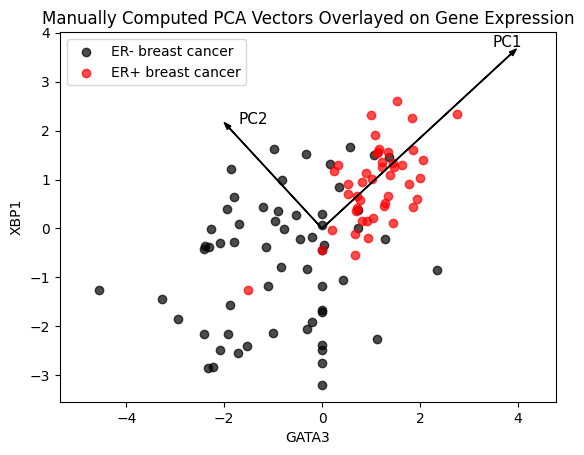

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get the data
X_vals = X
Y_vals = Y
Z_vals = Z

# Stack into 2D array

data = np.vstack((X_vals, Y_vals)).T
# Step 1: Center the data (mean subtraction)
mean = np.mean(data, axis=0)
data_centered = (data - mean)


# Step 2: Compute covariance matrix
cov_matrix = np.cov(data_centered.T)

# Step 3: Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

# Step 4: Sort eigenvectors by decreasing eigenvalue
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

# Step 5: Get principal components and explained variance
components = eig_vecs.T  # Same shape as PCA().components_
explained = eig_vals     # Same as explained_variance_

# Step 6: Prepare masks
mask0 = (Z_vals == 0)
mask1 = (Z_vals == 1)

# Plot
# plt.figure(figsize=(8, 6))
plt.scatter(data_centered[mask0, 0], data_centered[mask0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(data_centered[mask1, 0], data_centered[mask1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

# Plot principal component vectors
for i in range(2):
    # Arrow properties
    start = np.array([0, 0])
    end = np.sqrt(explained[i]) * components[i] * 3
    
    plt.arrow(start[0], start[1],
              end[0], end[1],
              color='black', width=0.01, head_width=0.1)
    
    # Add text label for PC1 and PC2
    plt.text(end[0]*0.9, end[1]*1.04, f'PC{i+1}', color='black', fontsize=11)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Manually Computed PCA Vectors Overlayed on Gene Expression")
plt.legend()
plt.axis('equal')
plt.show()


**3)** Generate Figure 1c

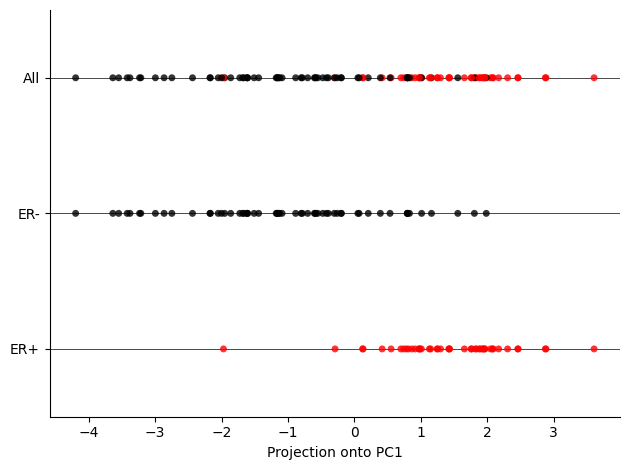

In [19]:

pc1_vector = eig_vecs[:, 0]

pc1_projection = data_centered @ pc1_vector

# Create rows for "All", "ER−", and "ER+" groups
df_all = pd.DataFrame({
    "PC1": pc1_projection,
    "Group": "All",
    "Color": np.where(Z == 0, "black", "red")
})

df_er_minus = pd.DataFrame({
    "PC1": pc1_projection[Z == 0],
    "Group": "ER-",
    "Color": "black"
})

df_er_plus = pd.DataFrame({
    "PC1": pc1_projection[Z == 1],
    "Group": "ER+",
    "Color": "red"
})

# Combine all
plot_df = pd.concat([df_all, df_er_minus, df_er_plus], ignore_index=True)

# Plot
ax = sns.stripplot(data=plot_df, x="PC1", y="Group", hue="Color", 
                   palette={"black": "black", "red": "red"}, 
                   dodge=False, jitter=False, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0) 

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)  # Remove legend
sns.despine()
plt.tight_layout()
plt.show()

